In [14]:
import numpy as np

file_name = input("What file do you want?") 


x, y = np.loadtxt(file_name, unpack=True)

print(x.min())
print(x.max())
print(x.mean())

print(y.min())
print(y.max())
print(y.mean())

y_med = np.median(y)

y2 = (y - y_med)**2

print(y2)

What file do you want? data.txt


0.0
13467.0
1400.2
15.0
346436.0
47065.7
[3.54025000e+03 3.80250000e+02 9.02500000e+01 2.50000000e-01
 2.50000000e-01 1.10250000e+02 1.19957976e+11 5.11225000e+03
 1.11222250e+05 1.51926578e+10]


In [3]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.concatenate((a, b)))

[1 2 3 4 5 6]


In [5]:
import numpy as np

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]]) 

print(np.concatenate((a ,b)))
print(np.concatenate((a ,b), axis=0))
print(np.concatenate((a ,b), axis=1))

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]


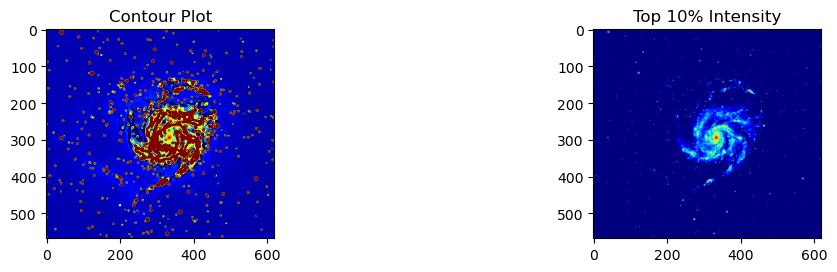

In [19]:
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np

data = imageio.imread("m101BW.jpg")

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(data, cmap ="jet")
plt.contour(data, levels = np.percentile(data, [90, 95, 97]), cmap = "jet")
plt.title("Contour Plot")

threshold = np.percentile(data, 90)
high = np.where(data >= threshold, data, threshold)

plt.subplot(1, 3, 3)
plt.imshow(high, cmap="jet")
plt.title("Top 10% Intensity")

plt.show()

[0.00482 0.00666 0.00705 0.00889 0.01269 0.02012 0.02789 0.03712 0.03985
 0.04617 0.0606  0.04935 0.02734 0.01746 0.0149  0.0247  0.03478 0.03472
 0.03174 0.02931 0.02995 0.02909 0.02687 0.0247  0.02483 0.02504 0.02486
 0.0228  0.01888 0.01625 0.01589 0.01473 0.01294 0.01236 0.01144 0.01118
 0.01038 0.00848 0.00751 0.0072 ]


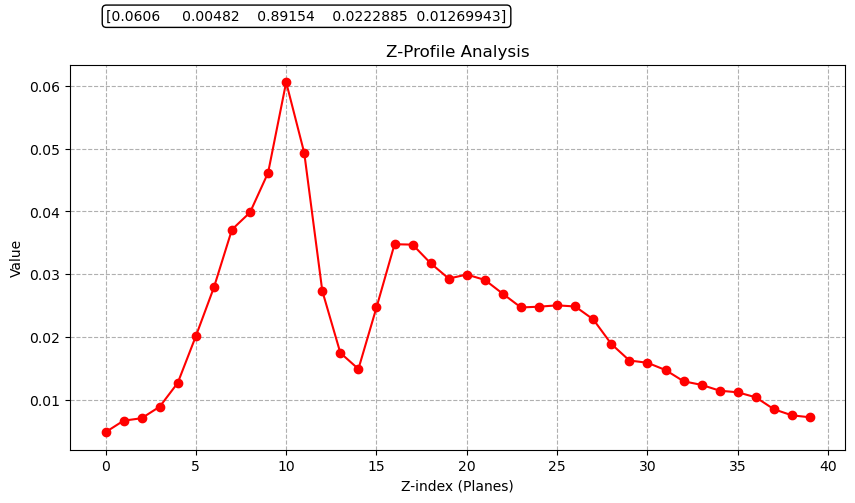

In [22]:
import numpy as np
import matplotlib.pyplot as plt

cube = np.loadtxt("ngc6946.txt").reshape((40, 50, 70))

y, x = 25, 35
z_profile = cube[:, y, x]

print(z_profile)

stats =np.array([np.max(z_profile), np.min(z_profile), np.sum(z_profile), np.mean(z_profile), np.std(z_profile)])

plt.figure(figsize=(10,5))
plt.plot(z_profile, marker="o", linestyle="-", color = "red", label = "Z-profile")

plt.text(0.05, 0.07, stats, verticalalignment='bottom', bbox=dict(boxstyle="round", facecolor="white"))

plt.title("Z-Profile Analysis")
plt.xlabel("Z-index (Planes)")
plt.ylabel("Value")
plt.grid(True, linestyle="--")
plt.show()

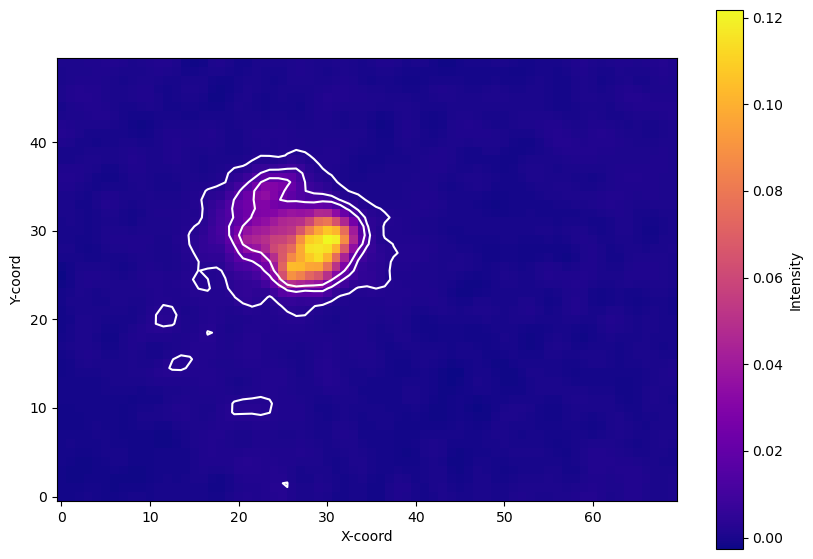

In [25]:
import numpy as np
import matplotlib.pyplot as plt
data = np.loadtxt('ngc6946.txt').reshape((40, 50, 70))

plane = data[0, :, :]

mu = np.mean(plane)
sigma = np.std(plane)
levels = [mu, mu + sigma, mu +2*sigma]

plt.figure(figsize=(10, 7))
img = plt.imshow(plane, origin = "lower", cmap = "plasma")
plt.colorbar(img, label="Intensity")

plt.contour(plane, levels=levels, colors = "white", origin="lower")
plt.xlabel('X-coord')
plt.ylabel('Y-coord')
plt.show()


In [3]:
from scipy.constants import c as cinitial


class Galaxy:
    """Class for redshift calculation of galaxies"""

    caH_0 = 3968.5 # Calcium H line in rest frame
    c = cinitial/1000

    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    def redshift(self):
        z = (self.caH - self.caH_0)/self.caH
        return z
    def velocity(self):
        z= self.redshift()
        v = z * self.c
        return v

galaxy = Galaxy("Messier 101", calciumHline = 4000)

gal_velocity = galaxy.velocity()

print(galaxy.redshift())
print(gal_velocity)

0.007875
2360.86560675


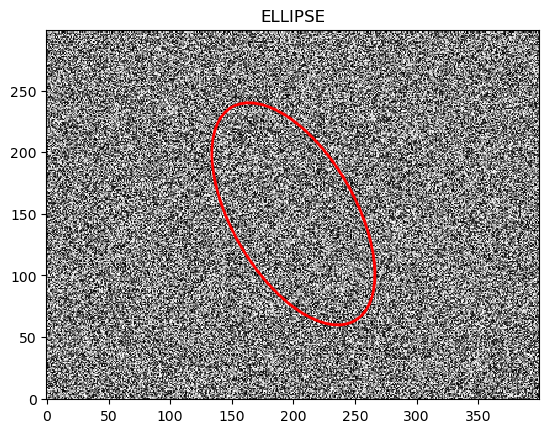

In [23]:
import numpy as np
from matplotlib.pyplot import figure, show
from matplotlib.patches import Ellipse
Nx = 400
Ny = 300
data = np.random.random((Ny, Nx))


fig, ax = plt.subplots()
ax.imshow(data, interpolation = 'none', origin='lower', cmap='gray')

center = (Nx/2, Ny/2)
width = 50*2
height = 100*2
angle = 30

ellipse = Ellipse(xy=center, width=width, height=height, angle=angle, edgecolor="red", facecolor="none",lw =2)

ax.add_patch(ellipse)

ax.set_title("ELLIPSE")
plt.show()

